# Experimento de Generalización Cruzada

Este notebook carga los 5 modelos entrenados de forma individual, los evalúa contra los 5 conjuntos de test separados y construye una matriz 5x5 de AUC. 
La diagonal representará el rendimiento intra-dataset (entrenado y evaluado en el mismo método), mientras que el resto de celdas mostrarán la capacidad de generalización cruzada.


In [1]:
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

from src.config import make_config, METHODS, CMAP_SEQUENTIAL, PROJECT_ROOT
from src.data import build_frame_dataframe, filter_by_method, get_transforms, DeepfakeDataset
from src.models import build_model
from src.engine import get_auc_for_loader

CONFIG = make_config(
    OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'cross_gen_xception',
    BATCH_SIZE = 64,
)
print(f"Device: {CONFIG['DEVICE']}")

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
_, val_transforms = get_transforms(CONFIG['IMG_SIZE'])

test_df_all = build_frame_dataframe(CONFIG['DATA_DIR'], splits=['test'])

test_loaders = {}
for method in METHODS:
    df_method = filter_by_method(test_df_all, method)
    dataset = DeepfakeDataset(df_method, val_transforms)
    test_loaders[method] = DataLoader(
        dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
        num_workers=CONFIG['NUM_WORKERS'], pin_memory=(CONFIG['DEVICE'] == 'cuda')
    )

print("DataLoaders de Test preparados.")

DataLoaders de Test preparados.


In [3]:
auc_matrix = pd.DataFrame(index=METHODS, columns=METHODS, dtype=float)

model = build_model('xception', CONFIG['DEVICE'])  # los pesos se pisan con cada checkpoint

for train_method in METHODS:
    print(f"\nEvaluando modelo entrenado en: {train_method}")
    ckpt_path = CONFIG['OUTPUT_DIR'] / f'best_{train_method}.pth'

    if not ckpt_path.exists():
        print(f"  [!] Checkpoint no encontrado: {ckpt_path}. Saltando...")
        continue

    ckpt = torch.load(ckpt_path, map_location=CONFIG['DEVICE'], weights_only=False)
    model.load_state_dict(ckpt['model_state'])

    for test_method in METHODS:
        auc = get_auc_for_loader(model, test_loaders[test_method], CONFIG['DEVICE'])
        auc_matrix.loc[train_method, test_method] = auc
        print(f"  vs {test_method}: AUC = {auc:.4f}")

auc_matrix.to_csv(CONFIG['OUTPUT_DIR'] / 'cross_generalization_matrix.csv')

/home/mariasarachaga/.local/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


xception — parámetros entrenables: 20,809,001

Evaluando modelo entrenado en: Deepfakes
  vs Deepfakes: AUC = 0.9623
  vs Face2Face: AUC = 0.6336
  vs FaceShifter: AUC = 0.6602
  vs FaceSwap: AUC = 0.6378
  vs NeuralTextures: AUC = 0.6015

Evaluando modelo entrenado en: Face2Face
  vs Deepfakes: AUC = 0.6182
  vs Face2Face: AUC = 0.9061
  vs FaceShifter: AUC = 0.5533
  vs FaceSwap: AUC = 0.5523
  vs NeuralTextures: AUC = 0.5610

Evaluando modelo entrenado en: FaceShifter
  vs Deepfakes: AUC = 0.7088
  vs Face2Face: AUC = 0.5174
  vs FaceShifter: AUC = 0.9686
  vs FaceSwap: AUC = 0.5641
  vs NeuralTextures: AUC = 0.6031

Evaluando modelo entrenado en: FaceSwap
  vs Deepfakes: AUC = 0.6891
  vs Face2Face: AUC = 0.5785
  vs FaceShifter: AUC = 0.6112
  vs FaceSwap: AUC = 0.9431
  vs NeuralTextures: AUC = 0.5014

Evaluando modelo entrenado en: NeuralTextures
  vs Deepfakes: AUC = 0.6802
  vs Face2Face: AUC = 0.5608
  vs FaceShifter: AUC = 0.6707
  vs FaceSwap: AUC = 0.4992
  vs NeuralTextur

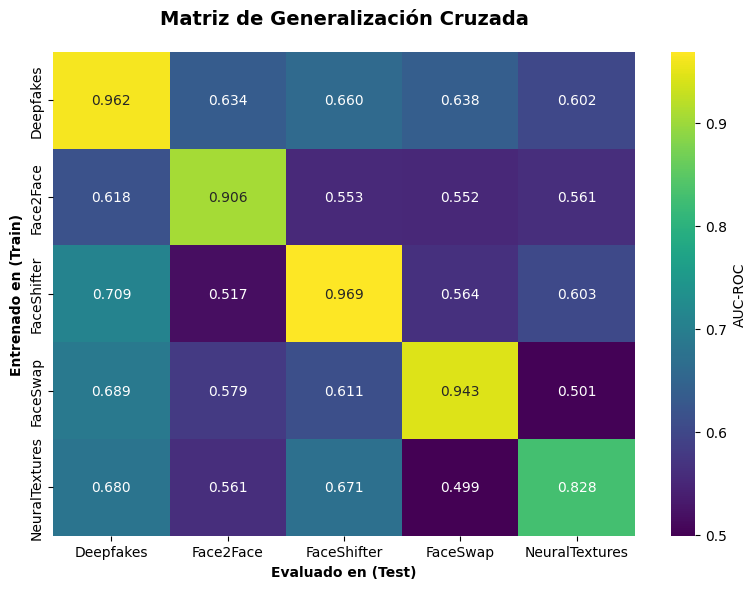

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(auc_matrix.astype(float), annot=True, fmt=".3f", cmap=CMAP_SEQUENTIAL,
            cbar_kws={'label': 'AUC-ROC'})
plt.title("Matriz de Generalización Cruzada", pad=20, fontsize=14, fontweight='bold')
plt.ylabel("Entrenado en (Train)", fontweight='bold')
plt.xlabel("Evaluado en (Test)", fontweight='bold')
plt.tight_layout()
plt.savefig(CONFIG['OUTPUT_DIR'] / 'cross_generalization_heatmap.png', dpi=150)
plt.show()